# 02. Baseline Oversampling Methods
**GA-Optimized G-CTGAN: An Automated Oversampling Framework for Imbalanced Data Classification**

This notebook runs all **baseline oversampling methods** across all datasets and classifiers,
and saves results to `results/02_baselines_results.csv`.

| Method | Type | Reference |
|--------|------|-----------|
| None   | Baseline (no oversampling) | — |
| SMOTE  | Interpolation | Chawla et al., 2002 |
| ADASYN | Adaptive interpolation | He et al., 2008 |
| G-SMOTE | GMM + Interpolation | — |
| CTGAN  | GAN-based | Xu et al., NeurIPS 2019 |
| TVAE   | VAE-based | Xu et al., NeurIPS 2019 |

> **Note:** CTAB-GAN+ is handled separately in `03_ctabgan.ipynb` (requires `env_ctabgan` kernel).


## 0. Setup

In [1]:
import os
import time
import warnings
import numpy as np
import pandas as pd
from pathlib import Path

warnings.filterwarnings("ignore")

# ── Paths ──────────────────────────────────────────────────────────────
DATASET_DIR  = "./datasets"
RESULTS_DIR  = "./results"
os.makedirs(RESULTS_DIR, exist_ok=True)

# ── Reproducibility ────────────────────────────────────────────────────
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ── Experiment scope ───────────────────────────────────────────────────
DATASET_NAMES = [
    "credit_default",
    "fraud_detection",
    "pima_diabetes",
    "ibm_attrition",
    "yeast_me2",
    "mammography",
    "abalone_19",
    "wine_quality",
    "ecoli",
    "pageblocks",
    "protein_homo",
]

OVERSAMPLING_METHODS = ["None", "SMOTE", "ADASYN", "G-SMOTE", "CTGAN", "TVAE"]
CLASSIFIERS          = ["RF", "LGBM", "MLP", "TabNet"]

# Unified minority ratio (Condition B — all methods set to 50%)
UNIFIED_RATIO = 0.50

print(f"Datasets  : {len(DATASET_NAMES)}")
print(f"Methods   : {OVERSAMPLING_METHODS}")
print(f"Classifiers: {CLASSIFIERS}")
print(f"Unified minority ratio: {UNIFIED_RATIO}")


Datasets  : 11
Methods   : ['None', 'SMOTE', 'ADASYN', 'G-SMOTE', 'CTGAN', 'TVAE']
Classifiers: ['RF', 'LGBM', 'MLP', 'TabNet']
Unified minority ratio: 0.5


## 1. Classifier Definitions

In [2]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from lightgbm import LGBMClassifier

# TabNet
try:
    from pytorch_tabnet.tab_model import TabNetClassifier
    TABNET_AVAILABLE = True
except ImportError:
    TABNET_AVAILABLE = False
    print("Warning: pytorch-tabnet not installed. TabNet will be skipped.")

def get_classifier(name, random_state=RANDOM_STATE):
    """Return a classifier instance by name with paper-consistent hyperparameters."""
    if name == "RF":
        return RandomForestClassifier(
            n_estimators=200,
            max_depth=10,
            min_samples_leaf=3,
            class_weight="balanced",
            random_state=random_state,
            n_jobs=-1,
        )
    elif name == "LGBM":
        return LGBMClassifier(
            n_estimators=100,
            learning_rate=0.05,
            num_leaves=31,
            class_weight="balanced",
            random_state=random_state,
            n_jobs=-1,
            verbose=-1,
        )
    elif name == "MLP":
        return MLPClassifier(
            hidden_layer_sizes=(128, 64),
            alpha=0.001,
            max_iter=300,
            random_state=random_state,
        )
    elif name == "TabNet" and TABNET_AVAILABLE:
        return TabNetClassifier(
            n_d=16, n_a=16, n_steps=3,
            gamma=1.3,
            n_independent=2, n_shared=2,
            mask_type="entmax",
            verbose=0,
            seed=random_state,
        )
    else:
        return None

print("Classifier factory ready.")


Classifier factory ready.


## 2. Evaluation Metrics

In [3]:
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score
)

def evaluate(model, X_test, y_test, model_name="RF"):
    """Compute AUC, F1, Precision, Recall for a fitted model."""
    if model_name == "TabNet":
        y_prob = model.predict_proba(X_test.values)[:, 1]
        y_pred = model.predict(X_test.values)
    else:
        y_prob = model.predict_proba(X_test)[:, 1]
        y_pred = model.predict(X_test)

    return {
        "AUC"      : round(roc_auc_score(y_test, y_prob), 4),
        "F1"       : round(f1_score(y_test, y_pred, zero_division=0), 4),
        "Precision": round(precision_score(y_test, y_pred, zero_division=0), 4),
        "Recall"   : round(recall_score(y_test, y_pred, zero_division=0), 4),
    }

print("Evaluation function ready.")


Evaluation function ready.


## 3. Oversampling Functions

In [4]:
from sklearn.mixture import GaussianMixture
from imblearn.over_sampling import SMOTE, ADASYN
from ctgan import CTGAN, TVAE

def compute_n_samples(y_train, target_ratio=UNIFIED_RATIO):
    """
    Compute number of synthetic minority samples needed
    to reach `target_ratio` minority proportion.

    target_ratio = n_minority_final / (n_minority_final + n_majority)
    => n_synthetic = n_majority * target_ratio / (1 - target_ratio) - n_minority
    """
    n_minority = int((y_train == 1).sum())
    n_majority = int((y_train == 0).sum())
    n_target   = int(n_majority * target_ratio / (1 - target_ratio))
    n_synthetic = max(0, n_target - n_minority)
    return n_synthetic

def apply_smote(X_train, y_train, random_state=RANDOM_STATE):
    sm = SMOTE(k_neighbors=3, random_state=random_state)
    return sm.fit_resample(X_train, y_train)

def apply_adasyn(X_train, y_train, random_state=RANDOM_STATE):
    ad = ADASYN(random_state=random_state)
    return ad.fit_resample(X_train, y_train)

def apply_gsmote(X_train, y_train, random_state=RANDOM_STATE):
    """
    G-SMOTE: GMM clustering on minority class, then SMOTE per cluster.
    Optimal k selected by BIC (search k=2..10).
    """
    X_min = X_train[y_train == 1]
    X_maj = X_train[y_train == 0]

    # BIC-based optimal k selection
    bic_scores = {}
    for k in range(2, min(11, len(X_min) // 2)):
        try:
            gmm = GaussianMixture(n_components=k, random_state=random_state)
            gmm.fit(X_min)
            bic_scores[k] = gmm.bic(X_min)
        except Exception:
            continue
    if not bic_scores:
        return apply_smote(X_train, y_train, random_state)

    best_k = min(bic_scores, key=bic_scores.get)
    gmm = GaussianMixture(n_components=best_k, random_state=random_state)
    gmm.fit(X_min)
    labels = gmm.predict(X_min)

    X_syn_list, y_syn_list = [], []
    for cluster_id in range(best_k):
        X_cluster = X_min[labels == cluster_id]
        if len(X_cluster) < 2:
            continue
        X_combined = np.vstack([X_maj, X_cluster])
        y_combined = np.array([0] * len(X_maj) + [1] * len(X_cluster))
        try:
            sm = SMOTE(k_neighbors=min(3, len(X_cluster) - 1), random_state=random_state)
            X_res, y_res = sm.fit_resample(X_combined, y_combined)
            X_new = X_res[len(X_combined):]
            y_new = y_res[len(X_combined):]
            X_syn_list.append(X_new)
            y_syn_list.append(y_new)
        except Exception:
            continue

    if not X_syn_list:
        return apply_smote(X_train, y_train, random_state)

    X_syn = np.vstack(X_syn_list)
    y_syn = np.concatenate(y_syn_list)
    X_out = np.vstack([X_train, X_syn])
    y_out = np.concatenate([y_train, y_syn])
    return X_out, y_out

def apply_ctgan(X_train, y_train, random_state=RANDOM_STATE):
    """CTGAN oversampling — trains on minority class, samples n_synthetic rows."""
    n_synthetic = compute_n_samples(y_train)
    if n_synthetic == 0:
        return X_train, y_train

    # Ensure pure float array and use generic column names
    X_min = X_train[y_train == 1].astype(float)
    cols  = [f"f{i}" for i in range(X_min.shape[1])]
    X_min_df = pd.DataFrame(X_min, columns=cols)

    model = CTGAN(epochs=100, verbose=False)
    model.fit(X_min_df)
    X_syn = model.sample(n_synthetic)

    X_out = np.vstack([X_train.astype(float), X_syn.values.astype(float)])
    y_out = np.concatenate([y_train, np.ones(n_synthetic, dtype=int)])
    return X_out, y_out

def apply_tvae(X_train, y_train, random_state=RANDOM_STATE):
    """TVAE oversampling — trains on minority class, samples n_synthetic rows."""
    n_synthetic = compute_n_samples(y_train)
    if n_synthetic == 0:
        return X_train, y_train

    # Ensure pure float array and use generic column names
    X_min = X_train[y_train == 1].astype(float)
    cols  = [f"f{i}" for i in range(X_min.shape[1])]
    X_min_df = pd.DataFrame(X_min, columns=cols)

    model = TVAE(epochs=100)
    model.fit(X_min_df)
    X_syn = model.sample(n_synthetic)

    X_out = np.vstack([X_train.astype(float), X_syn.values.astype(float)])
    y_out = np.concatenate([y_train, np.ones(n_synthetic, dtype=int)])
    return X_out, y_out

OVERSAMPLERS = {
    "None"   : None,
    "SMOTE"  : apply_smote,
    "ADASYN" : apply_adasyn,
    "G-SMOTE": apply_gsmote,
    "CTGAN"  : apply_ctgan,
    "TVAE"   : apply_tvae,
}

print("Oversampling functions ready.")


Oversampling functions ready.


## 4. Main Experiment Loop

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

results = []
TOTAL = len(DATASET_NAMES) * len(OVERSAMPLING_METHODS) * len(CLASSIFIERS)
done  = 0

for ds_name in DATASET_NAMES:
    # ── Load dataset ──────────────────────────────────────────────────
    path = os.path.join(DATASET_DIR, f"{ds_name}.csv")
    if not os.path.exists(path):
        print(f"[SKIP] {ds_name} — file not found")
        done += len(OVERSAMPLING_METHODS) * len(CLASSIFIERS)
        continue

    df = pd.read_csv(path)
    X  = df.drop(columns=["target"]).values.astype(float)
    y  = df["target"].values.astype(int)

    # Stratified 70/30 split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
    )

    # Standard scaling
    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    minority_ratio = y_train.mean()
    print(f"\n{'='*60}")
    print(f"Dataset : {ds_name}  |  n_train={len(X_train):,}  |  minority={minority_ratio:.2%}")
    print(f"{'='*60}")

    for method in OVERSAMPLING_METHODS:
        # ── Apply oversampling ────────────────────────────────────────
        t0 = time.time()
        try:
            if method == "None" or OVERSAMPLERS[method] is None:
                X_res, y_res = X_train.copy(), y_train.copy()
            else:
                X_res, y_res = OVERSAMPLERS[method](X_train.copy(), y_train.copy())
            oversample_time = round(time.time() - t0, 2)
        except Exception as e:
            print(f"  [{method}] Oversampling failed: {e}")
            done += len(CLASSIFIERS)
            continue

        n_min_res = int((y_res == 1).sum())
        n_maj_res = int((y_res == 0).sum())
        ratio_res = round(n_min_res / len(y_res), 4)

        for clf_name in CLASSIFIERS:
            done += 1
            progress = f"[{done:>4}/{TOTAL}]"

            clf = get_classifier(clf_name)
            if clf is None:
                print(f"  {progress} {ds_name} | {method:<8} | {clf_name:<7} — SKIPPED (not available)")
                continue

            # ── Train ──────────────────────────────────────────────────
            t1 = time.time()
            try:
                if clf_name == "TabNet":
                    X_tab = pd.DataFrame(X_res).values
                    clf.fit(
                        X_tab, y_res,
                        eval_set=[(scaler.transform(X_test), y_test)],
                        eval_name=["valid"],
                        eval_metric=["auc"],
                        max_epochs=200,
                        patience=20,
                        batch_size=256,
                        virtual_batch_size=128,
                        drop_last=False,
                    )
                else:
                    clf.fit(X_res, y_res)
                train_time = round(time.time() - t1, 2)
            except Exception as e:
                print(f"  {progress} {ds_name} | {method:<8} | {clf_name:<7} — Training failed: {e}")
                continue

            # ── Evaluate ───────────────────────────────────────────────
            try:
                X_test_eval = pd.DataFrame(X_test) if clf_name == "TabNet" else X_test
                metrics = evaluate(clf, X_test_eval, y_test, model_name=clf_name)
            except Exception as e:
                print(f"  {progress} {ds_name} | {method:<8} | {clf_name:<7} — Evaluation failed: {e}")
                continue

            row = {
                "dataset"         : ds_name,
                "oversampling"    : method,
                "classifier"      : clf_name,
                "n_train_resampled": len(y_res),
                "minority_ratio"  : ratio_res,
                "oversample_time" : oversample_time,
                "train_time"      : train_time,
                **metrics,
            }
            results.append(row)

            print(f"  {progress} {ds_name} | {method:<8} | {clf_name:<7} | "
                  f"AUC={metrics['AUC']:.4f}  F1={metrics['F1']:.4f}  "
                  f"[{train_time:.1f}s]")

print("\nExperiment complete.")



Dataset : credit_default  |  n_train=21,000  |  minority=22.12%
  [   1/264] credit_default | None     | RF      | AUC=0.7757  F1=0.5421  [0.6s]
  [   2/264] credit_default | None     | LGBM    | AUC=0.7787  F1=0.5330  [0.1s]
  [   3/264] credit_default | None     | MLP     | AUC=0.6961  F1=0.3856  [47.5s]
  [   4/264] credit_default | None     | TabNet  — SKIPPED (not available)
  [   5/264] credit_default | SMOTE    | RF      | AUC=0.7733  F1=0.5288  [0.8s]
  [   6/264] credit_default | SMOTE    | LGBM    | AUC=0.7719  F1=0.5101  [0.1s]
  [   7/264] credit_default | SMOTE    | MLP     | AUC=0.6901  F1=0.4335  [74.3s]
  [   8/264] credit_default | SMOTE    | TabNet  — SKIPPED (not available)
  [   9/264] credit_default | ADASYN   | RF      | AUC=0.7684  F1=0.5272  [0.8s]
  [  10/264] credit_default | ADASYN   | LGBM    | AUC=0.7680  F1=0.5086  [0.1s]
  [  11/264] credit_default | ADASYN   | MLP     | AUC=0.6788  F1=0.4080  [72.5s]
  [  12/264] credit_default | ADASYN   | TabNet  — SK

## 5. Save Results

In [6]:
results_df = pd.DataFrame(results)

save_path = os.path.join(RESULTS_DIR, "02_baselines_results.csv")
results_df.to_csv(save_path, index=False)
print(f"Results saved → {save_path}")
print(f"Total rows    : {len(results_df)}")
print()
print(results_df.groupby(["oversampling", "classifier"])["AUC"].mean().unstack().round(4).to_string())


Results saved → ./results\02_baselines_results.csv
Total rows    : 198

classifier      LGBM     MLP      RF
oversampling                        
ADASYN        0.8903  0.8566  0.8950
CTGAN         0.8872  0.8701  0.8815
G-SMOTE       0.8950  0.8561  0.8974
None          0.8887  0.8655  0.9022
SMOTE         0.8935  0.8604  0.8954
TVAE          0.8908  0.8573  0.8844


## 6. Summary Visualization

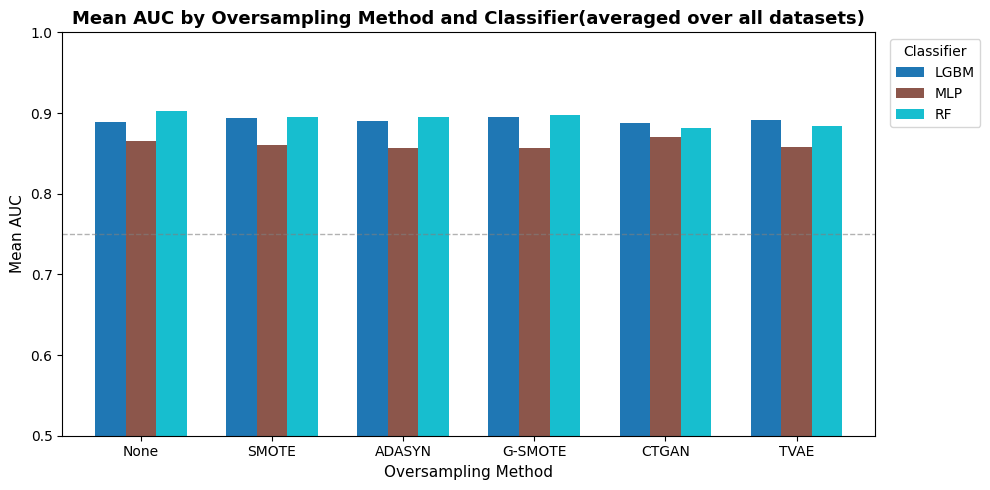

Figure saved → ./results\02_baselines_auc_summary.png


In [8]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ── Mean AUC by method × classifier ───────────────────────────────────
pivot = results_df.groupby(["oversampling", "classifier"])["AUC"].mean().unstack()
pivot = pivot.reindex(OVERSAMPLING_METHODS)

fig, ax = plt.subplots(figsize=(10, 5))
pivot.plot(kind="bar", ax=ax, width=0.7, colormap="tab10")
ax.set_title("Mean AUC by Oversampling Method and Classifier(averaged over all datasets)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Oversampling Method", fontsize=11)
ax.set_ylabel("Mean AUC", fontsize=11)
ax.set_ylim(0.5, 1.0)
ax.axhline(0.75, color="gray", linestyle="--", linewidth=1, alpha=0.6)
ax.legend(title="Classifier", bbox_to_anchor=(1.01, 1), loc="upper left")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()

fig_path = os.path.join(RESULTS_DIR, "02_baselines_auc_summary.png")
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure saved → {fig_path}")
